In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from sklearn.metrics import mean_absolute_error
from matplotlib.cbook import boxplot_stats
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAXResults
from matplotlib.animation import FuncAnimation
from math import sqrt
import itertools

* Dividir série em treino e teste
* Transformar a série em estacionária
* Procurar lags correlacionados
* Criar o modelo
* Plotar o gráfico comparativo na base de treino
* Avaliar o modelo e o erro na base de testes
* Sugerir possíveis melhorias do modelo.

Ler os dados, ordenar por data, remover os nulos e as praias com poucos dados

In [2]:
parser = (lambda x:datetime.datetime.strptime(x, '%Y.%m.%d')) 
df = pd.read_csv('sp_beaches_update.csv', parse_dates=['Date'])
df = df.sort_values(by=['Date'])
df=df.loc[~df['Enterococcus'].isnull()]
#remover a praia do Leste, da cidade de iguape, pois esta praia sumiu por erosão em 2012
#remover a Lagoa Prumirim, da cidade de Ubatuba, pois esta praia possui somente 3 medições
df = df.loc[df['Beach']!='DO LESTE'].loc[df['Beach']!='LAGOA PRUMIRIM']
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 69016 entries, 0 to 66721
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   City          69016 non-null  object        
 1   Beach         69016 non-null  object        
 2   Date          69016 non-null  datetime64[ns]
 3   Enterococcus  69016 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 2.6+ MB


Selecionar os dados de uma praia especifica e separa treino e teste

             y
ds            
2012-01-03   5
2012-01-08  42
2012-01-15  92
2012-01-22  16
2012-01-29   9
...         ..
2020-02-16   9
2020-02-23  24
2020-03-01   2
2020-03-08  17
2020-03-15   2

[419 rows x 1 columns]
              y
ds             
2020-07-27    3
2020-08-03    2
2020-08-10    1
2020-08-17    3
2020-08-24    2
2020-08-31    2
2020-09-07   17
2020-09-14   14
2020-09-21  120
2020-09-28   16


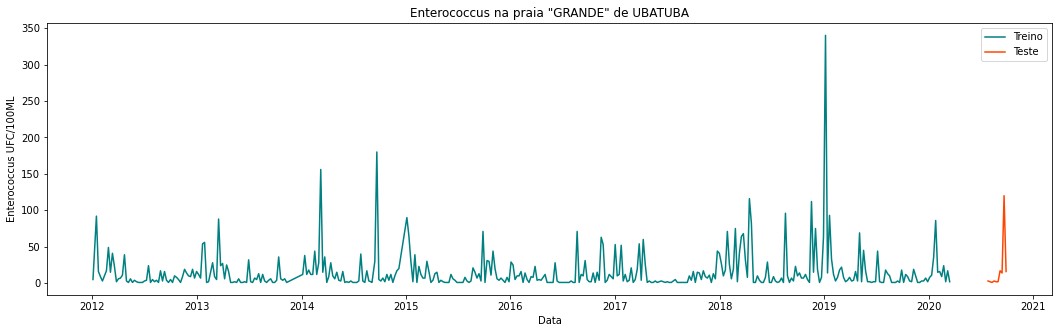

In [3]:
cidade="UBATUBA"
praia="GRANDE"
test_size=10

df_beach = df.loc[df['City']==cidade].loc[df['Beach']==praia][['Date','Enterococcus']]
df_beach.columns = ['ds', 'y']
df_beach.set_index('ds', inplace=True)

treino = df_beach.iloc[:-test_size,0:1].copy()
teste = df_beach.iloc[-test_size:,0:1].copy()

print(treino)
print(teste)
plt.figure(figsize=(18,5))
plt.title('Enterococcus na praia "'+praia+'" de '+cidade)
plt.plot(treino, color='teal')
plt.plot(teste, color='orangered')
plt.legend(['Treino','Teste'])
plt.xlabel('Data')
plt.ylabel('Enterococcus UFC/100ML')
plt.show()

Definir as datas que serão previstas

In [4]:
future=df_beach.loc[df_beach.index[-test_size:]].index
future

DatetimeIndex(['2020-07-27', '2020-08-03', '2020-08-10', '2020-08-17',
               '2020-08-24', '2020-08-31', '2020-09-07', '2020-09-14',
               '2020-09-21', '2020-09-28'],
              dtype='datetime64[ns]', name='ds', freq=None)

Transformar a série em estacionária

checar estacionariedade

In [5]:
def checar_estacionariedade(y, lags_plots=48, figsize=(22,8)):
    "Use Series como parâmetro"
    
    # Criando plots do DF
    #y = pd.Series(y)
    fig = plt.figure()
    ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=2)
    ax2 = plt.subplot2grid((3, 3), (1, 0))
    ax3 = plt.subplot2grid((3, 3), (1, 1))
    ax4 = plt.subplot2grid((3, 3), (2, 0), colspan=2)
    y.plot(ax=ax1, figsize=figsize, color='teal')
    ax1.set_title('Série de medições')
    plot_acf(y, lags=lags_plots, zero=False, ax=ax2, color='teal');
    plot_pacf(y, lags=lags_plots, zero=False, ax=ax3, method='ols', color='teal');
    sns.distplot(y, bins=int(sqrt(len(y))), ax=ax4, color='teal')
    ax4.set_title('Distribuição dos medições')
    plt.tight_layout()
    
    print('Resultados do teste de Dickey-Fuller:')
    adfinput = adfuller(y)
    adftest = pd.Series(adfinput[0:4], index=['Teste Statistico','Valor-P','Lags Usados','Números de Observações'])
    adftest = round(adftest,4)
    
    for key, value in adfinput[4].items():
        adftest["Valores Críticos (%s)"%key] = value.round(4)
        
    print(adftest)

C:\Users\User\anaconda3\envs\balneabilidade\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Resultados do teste de Dickey-Fuller:
Teste Statistico           -5.8361
Valor-P                     0.0000
Lags Usados                 6.0000
Números de Observações    412.0000
Valores Críticos (1%)      -3.4463
Valores Críticos (5%)      -2.8686
Valores Críticos (10%)     -2.5705
dtype: float64


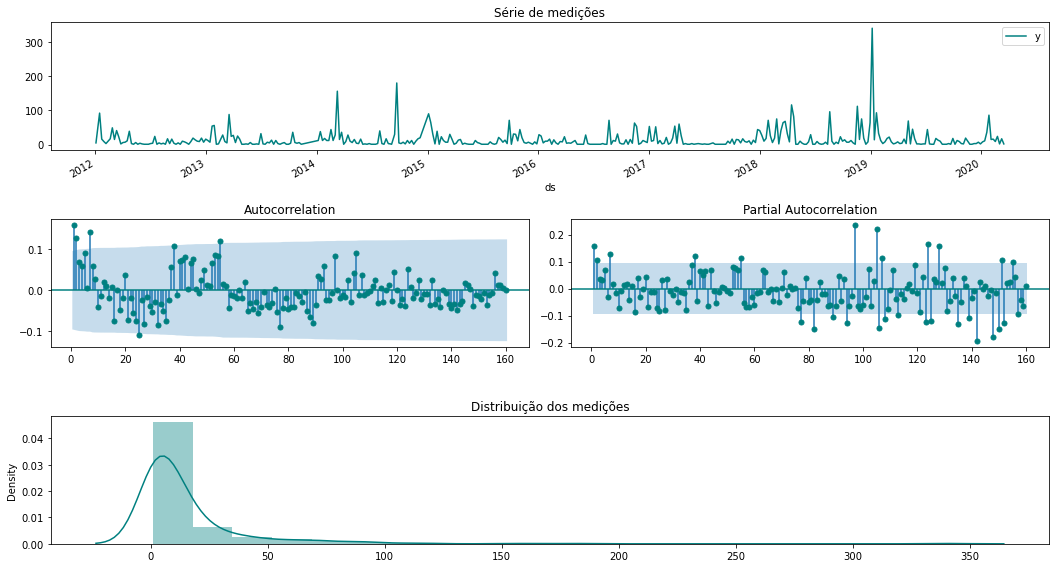

In [13]:
checar_estacionariedade(treino, lags_plots=160)

C:\Users\User\anaconda3\envs\balneabilidade\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Resultados do teste de Dickey-Fuller:
Teste Statistico          -10.8487
Valor-P                     0.0000
Lags Usados                 7.0000
Números de Observações    410.0000
Valores Críticos (1%)      -3.4464
Valores Críticos (5%)      -2.8686
Valores Críticos (10%)     -2.5705
dtype: float64


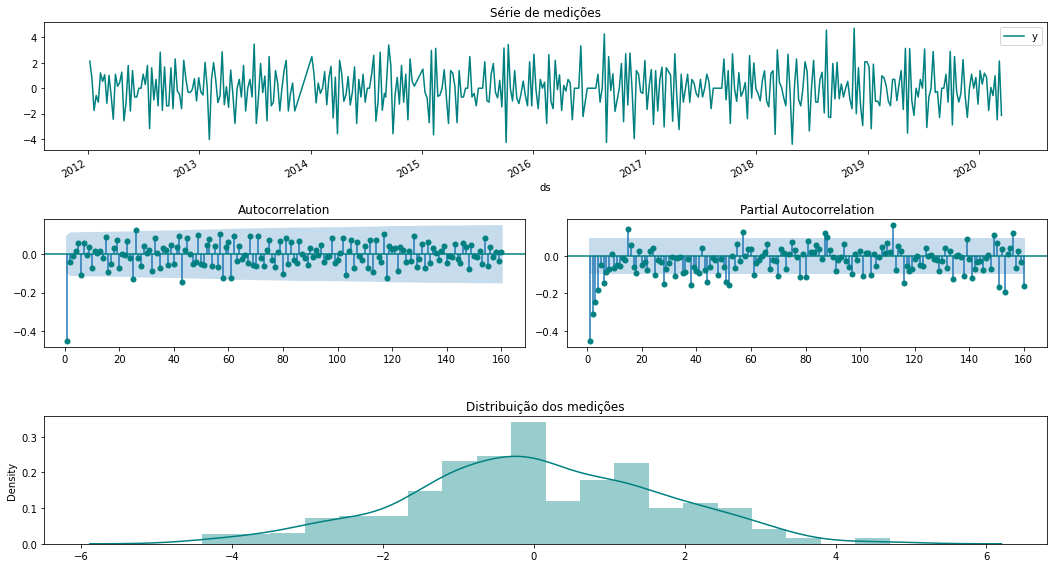

In [6]:
treinoLogDiff = np.log(treino).diff().dropna()
checar_estacionariedade(treinoLogDiff, lags_plots=160)

C:\Users\User\anaconda3\envs\balneabilidade\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: the 'freq'' keyword is deprecated, use 'period' instead
  """Entry point for launching an IPython kernel.


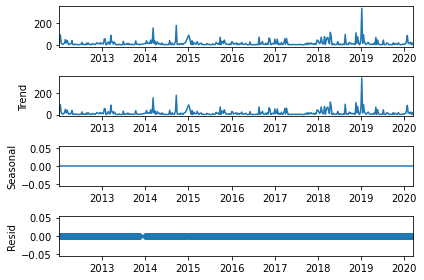

In [7]:

decomposition = sm.tsa.seasonal_decompose(treino, model='additive', freq=1)
fig = decomposition.plot()
plt.show()


In [ ]:
p = range(0, 6)
d = range(0, 2)
q = range(0, 1)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 52) for x in list(itertools.product(p, d, q))]
print('Examples of parameter for SARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

In [ ]:
import warnings
warnings.filterwarnings("ignore")
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(treinoLogDiff,order=param,seasonal_order=param_seasonal,enforce_stationarity=False,enforce_invertibility=False)
            results = mod.fit()
            print('ARIMA{}x{}12 - AIC:{}'.format(param,param_seasonal,results.aic))
        except: 
            continue

In [8]:
mod = sm.tsa.statespace.SARIMAX(treino,
            order=(1, 0, 0),
            seasonal_order=(5, 1, 0, 52),
            enforce_stationarity=False,
            enforce_invertibility=False)
results = mod.fit()
print(results.summary().tables[1])

C:\Users\User\anaconda3\envs\balneabilidade\lib\site-packages\statsmodels\tsa\base\tsa_model.py:218: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
C:\Users\User\anaconda3\envs\balneabilidade\lib\site-packages\statsmodels\tsa\base\tsa_model.py:218: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0581      0.150      0.388      0.698      -0.235       0.351
ar.S.L52      -0.9949      0.397     -2.505      0.012      -1.773      -0.216
ar.S.L104     -0.5286      0.464     -1.139      0.255      -1.438       0.381
ar.S.L156     -0.3808      0.472     -0.807      0.420      -1.306       0.544
ar.S.L208     -0.0602      0.436     -0.138      0.890      -0.915       0.795
ar.S.L260     -0.2057      0.364     -0.565      0.572      -0.919       0.508
sigma2      1510.2187    111.859     13.501      0.000    1290.978    1729.459


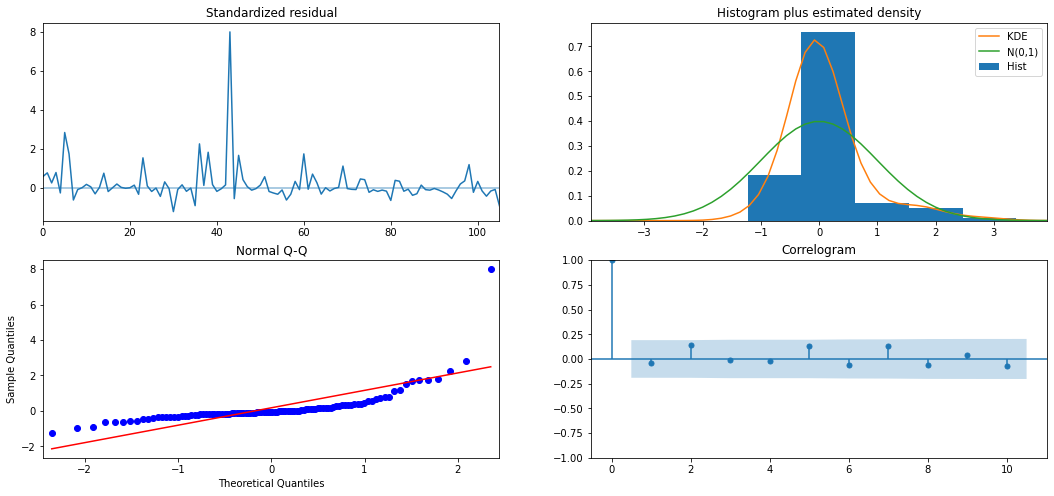

In [9]:
results.plot_diagnostics(figsize=(18, 8))
plt.show()

C:\Users\User\anaconda3\envs\balneabilidade\lib\site-packages\statsmodels\tsa\base\tsa_model.py:583: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)


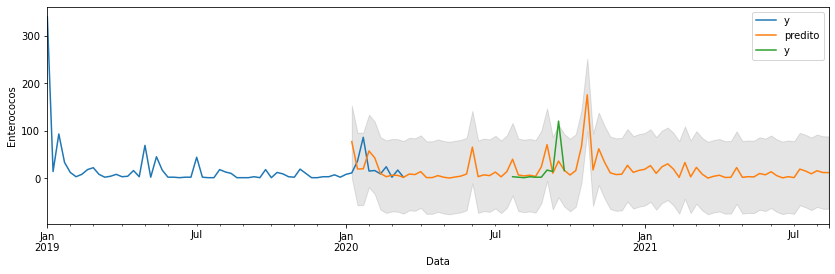

In [10]:
import datetime as dt
pred_uc = results.get_forecast(steps=84)
index_date = pd.date_range(treino.index[-10], periods = 84, freq = 'W')
forecast_series = pd.Series(list(pred_uc.predicted_mean), index = index_date)
pred_ci = pred_uc.conf_int()
ax = treino['2019':].plot(label='treino', figsize=(14, 4))
#print(pred_uc.predicted_mean)
forecast_series.plot(ax=ax, label='predito')
teste.plot(ax=ax, label='teste')
ax.fill_between(forecast_series.index,
 pred_ci.iloc[:, 0],
 pred_ci.iloc[:, 1], color='k', alpha=.1)
ax.set_xlabel('Data')
ax.set_ylabel('Enterococos')
plt.legend()
plt.show()

In [18]:
results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  419
Model:             SARIMAX(5, 0, 0)x(5, 1, 0, 52)   Log Likelihood                -516.158
Date:                            Thu, 08 Oct 2020   AIC                           1054.316
Time:                                    14:52:42   BIC                           1083.191
Sample:                                         0   HQIC                          1066.008
                                            - 419                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0354      0.162      0.218      0.827      -0.283       0.353
ar.L2          0.1684      0.185      0.912      0.362      -0.194       0.531
ar.L3         -0.0089      0.208     -0.043      0.966      -0.417       0.399
ar.L4         -0.0031      0.260     -0.012      0.990      -0.512       0.506
ar.L5          0.1735      0.090      1.933      0.053      -0.002       0.350
ar.S.L52      -1.0095      0.392     -2.577      0.010      -1.777      -0.242
ar.S.L104     -0.4952      0.457     -1.083      0.279      -1.392       0.401
ar.S.L156     -0.2469      0.434     -0.569      0.569      -1.097       0.604
ar.S.L208      0.0948      0.411      0.231      0.818      -0.711       0.900
ar.S.L260     -0.0239      0.378     -0.063      0.949      -0.764       0.716
sigma2      1455.1938    126.764     11.480      0.000    1206.740    1703.647
===================================================================================
Ljung-Box (Q):                       34.85   Jarque-Bera (JB):              4770.21
Prob(Q):                              0.70   Prob(JB):                         0.00
Heteroskedasticity (H):               0.26   Skew:                             4.72
Prob(H) (two-sided):                  0.00   Kurtosis:                        35.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
from sklearn.metrics import mean_squared_error
#pred = results.predict('2020-08-24','2020-09-28',exog = teste)[1:]
#forecast_series
print(forecast_series['2020-07-20':'2020-09-28'])
print(df_beach['2020-07-27':'2020-09-28'])
print('ARIMAX model MSE:{}'.format(mean_squared_error(df_beach['2020-07-27':'2020-09-28'],forecast_series['2020-07-20':'2020-09-28'])))

2020-07-26    39.832286
2020-08-02     6.695806
2020-08-09     4.717505
2020-08-16     6.199027
2020-08-23     3.639927
2020-08-30    23.682675
2020-09-06    70.541254
2020-09-13    10.396339
2020-09-20    36.031877
2020-09-27    16.554561
Freq: W-SUN, dtype: float64
              y
ds             
2020-07-27    3
2020-08-03    2
2020-08-10    1
2020-08-17    3
2020-08-24    2
2020-08-31    2
2020-09-07   17
2020-09-14   14
2020-09-21  120
2020-09-28   16
ARIMAX model MSE:1180.6154842334208


[  3   2   1   3   2   2  17  14 120  16]
[39.83228589  6.69580637  4.71750502  6.1990269   3.63992675 23.68267543
 70.5412543  10.3963386  36.03187661 16.55456069]


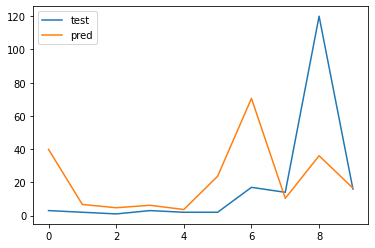

In [12]:
print(df_beach['2020-07-20':'2020-09-28'].to_numpy().reshape((10)))
print(forecast_series['2020-07-20':'2020-09-28'].to_numpy())
pd.DataFrame({'test':df_beach['2020-07-20':'2020-09-28'].to_numpy().reshape((10)),'pred':forecast_series['2020-07-20':'2020-09-28'].to_numpy()}).plot();
plt.show()

In [13]:
results.save('model.pkl')